# 7 baseline — 발전용 가스수요 Prophet 가벼운 베이스라인

> 목적: `7. land_gas_forecaster`의 **가벼운 시간기반 베이스라인**. 외생변수(net_load 등)를 전혀 쓰지 않고
> 순수 시간 패턴(일·주·연 계절성)만으로 `gen_gas_kr`을 어디까지 설명하는지 본다. 본 모델(7-A LGBM, test MAPE 11.4%)과 대비되는 하한선.

**핵심 결정**: `add_regressor`를 쓰지 않는다 — net_load 제외가 이번 베이스라인의 정의다. (외생변수를 넣는 순간 베이스라인이 아니라 또 하나의 본 모델이 된다.)

## 데이터·학습창
- `input_data_land.db` `historical`, 타깃 `gen_gas_kr`(시간단위).
- **G-10**: 2020–2021은 실측이 아니라 결측을 0으로 채운 값 → **2022-01부터 로드**.
- 분할(7-A 동일): **train 2022–24 / val 2025 / test 2026**. test 2026은 1~6월 부분구간(~3,700행)이라 MAPE 해석 시 감안.
- 시간 인덱스 연속성은 A0에서 0(구멍 없음)으로 확인됨. Prophet 입력은 `ds`(tz-naive) / `y`.

## 모델 구성
1. **seasonal naive (lag168)** — `ŷ(t)=y(t-168)`. 같은 요일·시각 1주 전 실측. 최근 실측을 그대로 쓰는 바닥선.
2. **Prophet ×8** — daily·weekly 계절성 켬 + 격자:
   - yearly 계절성 **on/off** (2022~ 길이상 연주기 효과가 약할 수 있어 둘 다 확인)
   - 계절성 **가법(additive) vs 승법(multiplicative)** (가스 수요는 수준에 따라 진폭이 변할 수 있음)
   - 휴일 **없음 vs 한국 공휴일(KR)** — `day_type`은 외생변수가 아니라 달력 파생이라 시간 패턴에 넣어도 됨. 다만 "순수 시간만"의 경계를 분명히 하려고 **별도 variant로 분리**.

> 평가 방식: Prophet은 train(2022–24)으로 한 번 적합한 뒤 2025–26 전체를 외삽 예측(순수 시간 외삽력 측정). seasonal naive는 1주 전 실측을 쓰므로 정보 조건이 다르다 — 둘은 다른 정보량의 하한선이며, 그 대비 자체가 정보가 된다(아래 결론 참조).


In [13]:
import warnings, logging, os
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

import sqlite3
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
mpl.rcParams['font.family']='Malgun Gothic'; mpl.rcParams['axes.unicode_minus']=False
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
DB=Path('../../1. data_fetcher_and_db/data/input_data_land.db')
print('DB exists:', DB.exists())


DB exists: True


## 1. 데이터 적재 — historical, 2022-01부터(G-10), ds/y 포맷

In [14]:
con=sqlite3.connect(DB)
raw=pd.read_sql('SELECT timestamp, gen_gas_kr FROM historical ORDER BY timestamp', con, parse_dates=['timestamp'])
con.close()
print('원본 행수:', len(raw), '| 기간', raw.timestamp.min(), '->', raw.timestamp.max())

# G-10: 2020-2021은 결측-0 → 제외
df=raw[raw.timestamp>='2022-01-01'].copy()
n_before=len(df)
df=df.dropna(subset=['gen_gas_kr'])           # test 2026 말미 미수집 14행 등 제거
print(f'2022+ 적재 {n_before}행 → 결측 제거 후 {len(df)}행 (NaN {n_before-len(df)}개 drop)')

df=df.rename(columns={'timestamp':'ds','gen_gas_kr':'y'}).reset_index(drop=True)
df['ds']=pd.to_datetime(df['ds']).dt.tz_localize(None)   # tz-naive 보장

# 시간 연속성 점검(구멍 = 1시간 간격이 아닌 곳)
gaps=df['ds'].diff().dropna()
n_gap=(gaps!=pd.Timedelta(hours=1)).sum()
print('1시간 간격이 아닌 지점 수(구멍/중복):', int(n_gap))

def split(a,b):
    m=(df['ds']>=a)&(df['ds']<b); return df[m].copy()
tr=split('2022-01-01','2025-01-01'); va=split('2025-01-01','2026-01-01'); te=split('2026-01-01','2027-01-01')
print(f'train {len(tr)} | val {len(va)} | test {len(te)}')
print('test 기간', te.ds.min(),'->',te.ds.max())


원본 행수: 56424 | 기간 2020-01-01 00:00:00 -> 2026-06-09 23:00:00
2022+ 적재 38880행 → 결측 제거 후 38866행 (NaN 14개 drop)
1시간 간격이 아닌 지점 수(구멍/중복): 1
train 26304 | val 8760 | test 3802
test 기간 2026-01-01 00:00:00 -> 2026-06-09 19:00:00


## 2. 평가지표
`MAPE`는 1차 지표(가스 최솟값 ≈4,800MW로 분모 안정). R²는 시간외삽 설명력.

In [15]:
def metrics(y,p):
    y=np.asarray(y,float); p=np.asarray(p,float)
    return dict(MAE=mean_absolute_error(y,p),
                RMSE=mean_squared_error(y,p)**0.5,
                MAPE=np.mean(np.abs((y-p)/y))*100,
                R2=r2_score(y,p))

def eval_on(pred_df, name):
    """pred_df: ds,yhat 전체. val/test로 잘라 실측과 ds 기준 병합 후 지표."""
    out={}
    for sp,frame in [('val',va),('test',te)]:
        mrg=frame[['ds','y']].merge(pred_df[['ds','yhat']], on='ds', how='inner').dropna()
        out[(name,sp)]=metrics(mrg['y'], mrg['yhat'])
    return out


## 3. seasonal naive (lag168) — 바닥 베이스라인
`ŷ(t)=y(t-168)`. 전체 2022+ 연속 시계열에서 168시간(7일) 시프트. val 초반 일부는 train 말미 실측을 참조한다.

In [16]:
naive=df[['ds','y']].copy()
naive['yhat']=naive['y'].shift(168)          # 연속 시계열 기준 1주 전 값
m_naive=eval_on(naive[['ds','yhat']].assign(yhat=naive['yhat']), 'seasonal_naive(lag168)')
print({k:{kk:round(vv,2) for kk,vv in v.items()} for k,v in m_naive.items()})


{('seasonal_naive(lag168)', 'val'): {'MAE': 3127.28, 'RMSE': 4284.38, 'MAPE': 18.11, 'R2': 0.51}, ('seasonal_naive(lag168)', 'test'): {'MAE': 3303.14, 'RMSE': 4737.87, 'MAPE': 19.02, 'R2': 0.39}}


## 4. Prophet ×8 — 시간 패턴만
train(2022–24)으로 적합 → 2025–26 전체 외삽 예측. `uncertainty_samples=0`(구간추정 생략)으로 가볍게.

In [ ]:
def run_prophet(yearly, mode, holidays):
    m=Prophet(growth='linear',
              yearly_seasonality=yearly,
              weekly_seasonality=True,
              daily_seasonality=True,
              seasonality_mode=mode,
              uncertainty_samples=0)
    if holidays:
        m.add_country_holidays(country_name='KR')
    m.fit(tr[['ds','y']])
    future=df[['ds']].copy()                  # 실측이 있는 전체 ds에 대해 예측
    fc=m.predict(future)
    return fc[['ds','yhat']]

grid=[]
for yearly in [False, True]:
    for mode in ['additive','multiplicative']:
        for hol in [False, True]:
            grid.append((yearly,mode,hol))

def label(yearly,mode,hol):
    return f"Prophet[{'mult' if mode=='multiplicative' else 'add'}|yr_{'on' if yearly else 'off'}|{'KR휴일' if hol else 'no휴일'}]"

all_metrics={}; preds={}
for yearly,mode,hol in grid:
    name=label(yearly,mode,hol)
    def run_prophet(yearly, mode, holidays):
        m = Prophet(growth='linear',
                    yearly_seasonality=yearly,
                    weekly_seasonality=True,
                    daily_seasonality=True,
                    seasonality_mode=mode,
                    uncertainty_samples=0)
        if not hasattr(m, 'stan_backend'):
            m.stan_backend = StanBackendEnum.CMDSTANPY
        if holidays:
            m.add_country_holidays(country_name='KR')
        m.fit(tr[['ds','y']])
        future = df[['ds']].copy()
        fc = m.predict(future)
        return fc[['ds','yhat']]

    grid=[]
    for yearly in [False, True]:
        for mode in ['additive','multiplicative']:
            for hol in [False, True]:
                grid.append((yearly,mode,hol))

    def label(yearly,mode,hol):
        return f"Prophet[{'mult' if mode=='multiplicative' else 'add'}|yr_{'on' if yearly else 'off'}|{'KR휴일' if hol else 'no휴일'}]"

    all_metrics={}; preds={}
    for yearly,mode,hol in grid:
        name=label(yearly,mode,hol)
        fc=run_prophet(yearly,mode,hol)
        preds[name]=fc
        all_metrics.update(eval_on(fc, name))
        mt=all_metrics[(name,'test')]
        print(f"{name:42s} test MAPE {mt['MAPE']:5.2f}%  R2 {mt['R2']:+.3f}")
    preds[name]=fc
    all_metrics.update(eval_on(fc, name))
    mt=all_metrics[(name,'test')]
    print(f"{name:42s} test MAPE {mt['MAPE']:5.2f}%  R2 {mt['R2']:+.3f}")


AttributeError: 'Prophet' object has no attribute 'stan_backend'

## 5. 결과표 — 9개 모델 × (val·test)

In [ ]:
rows=[]
src={**m_naive, **all_metrics}
for (name,sp),v in src.items():
    rows.append(dict(model=name, split=sp, **{k:round(val,2) for k,val in v.items()}))
res=pd.DataFrame(rows)
res=res.sort_values(['split','MAPE']).reset_index(drop=True)
res.to_csv(TAB/'metrics.csv', index=False, encoding='utf-8-sig')
# 보기 좋은 피벗(MAPE 중심)
pv=res.pivot(index='model', columns='split', values='MAPE').rename(columns=lambda c:f'MAPE_{c}')
pv=pv.sort_values('MAPE_test')
print(pv.round(2).to_string())
print('\n저장: tab/metrics.csv')
res


split                      MAPE_test  MAPE_val
model                                         
seasonal_naive(lag168)         19.02     18.11
Prophet[add|yr_on|KR휴일]        20.92     23.70
Prophet[mult|yr_on|no휴일]       20.94     22.67
Prophet[add|yr_on|no휴일]        21.43     24.84
Prophet[mult|yr_on|KR휴일]       21.97     21.30
Prophet[mult|yr_off|KR휴일]      25.39     24.92
Prophet[mult|yr_off|no휴일]      25.96     25.66
Prophet[add|yr_off|KR휴일]       26.02     25.70
Prophet[add|yr_off|no휴일]       26.72     26.50

저장: tab/metrics.csv


,model,split,MAE,RMSE,MAPE,R2
0,seasonal_naive(lag168),test,3303.14,4737.87,19.02,0.39
1,Prophet[add|yr_on|KR휴일],test,3662.47,4648.11,20.92,0.41
2,Prophet[mult|yr_on|no휴일],test,3556.85,4637.96,20.94,0.41
3,Prophet[add|yr_on|no휴일],test,3626.95,4674.83,21.43,0.41
4,Prophet[mult|yr_on|KR휴일],test,4103.65,5069.50,21.97,0.30
5,Prophet[mult|yr_off|KR휴일],test,4190.01,5274.36,25.39,0.24
6,Prophet[mult|yr_off|no휴일],test,4251.37,5371.78,25.96,0.22
7,Prophet[add|yr_off|KR휴일],test,4203.84,5301.13,26.02,0.24
8,Prophet[add|yr_off|no휴일],test,4273.60,5409.96,26.72,0.20
9,seasonal_naive(lag168),val,3127.28,4284.38,18.11,0.51


In [ ]:
# 최고 Prophet variant(test MAPE 최소)와 naive 식별
prophet_rows=res[(res.split=='test') & (res.model.str.startswith('Prophet'))]
best_name=prophet_rows.sort_values('MAPE').iloc[0]['model']
best_test=all_metrics[(best_name,'test')]; best_val=all_metrics[(best_name,'val')]
naive_test=m_naive[('seasonal_naive(lag168)','test')]
print('best Prophet :', best_name)
print('  val :', {k:round(v,2) for k,v in best_val.items()})
print('  test:', {k:round(v,2) for k,v in best_test.items()})
print('naive  test :', {k:round(v,2) for k,v in naive_test.items()})


best Prophet : Prophet[add|yr_on|KR휴일]
  val : {'MAE': 3678.66, 'RMSE': 4515.53, 'MAPE': 23.7, 'R2': 0.46}
  test: {'MAE': 3662.47, 'RMSE': 4648.11, 'MAPE': 20.92, 'R2': 0.41}
naive  test : {'MAE': 3303.14, 'RMSE': 4737.87, 'MAPE': 19.02, 'R2': 0.39}


## 6. 그림 — test 2026 예측 vs 실측 (best Prophet · seasonal naive)

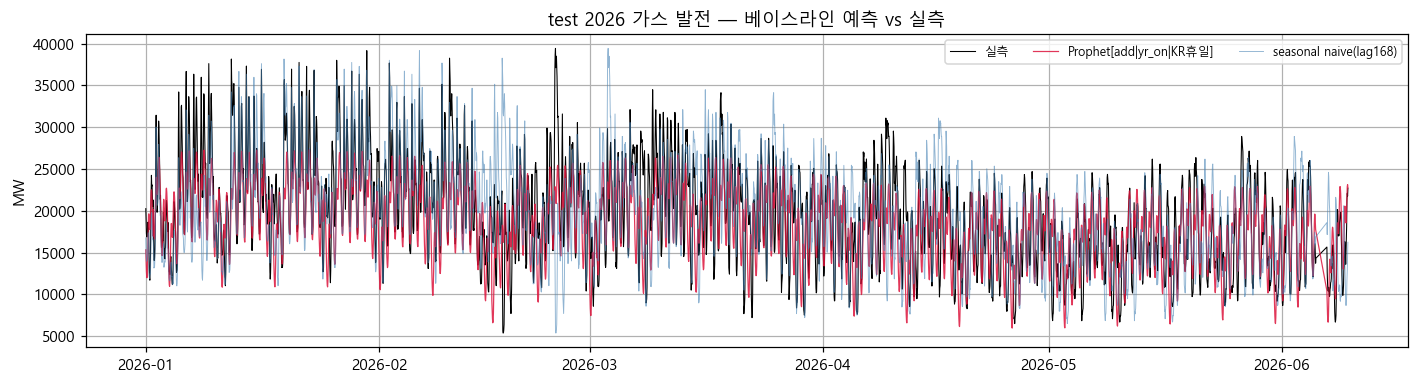

In [ ]:
best_fc=preds[best_name].merge(te[['ds','y']], on='ds', how='inner')
naive_te=naive[['ds','yhat']].merge(te[['ds','y']], on='ds', how='inner').dropna()

fig,ax=plt.subplots(figsize=(13,3.6))
ax.plot(best_fc['ds'], best_fc['y'], color='black', lw=0.7, label='실측')
ax.plot(best_fc['ds'], best_fc['yhat'], color='crimson', lw=0.8, alpha=0.85, label=f'{best_name}')
ax.plot(naive_te['ds'], naive_te['yhat'], color='steelblue', lw=0.6, alpha=0.6, label='seasonal naive(lag168)')
ax.set_title('test 2026 가스 발전 — 베이스라인 예측 vs 실측'); ax.set_ylabel('MW'); ax.legend(loc='upper right', ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'baseline_test_timeseries.png'); plt.show()


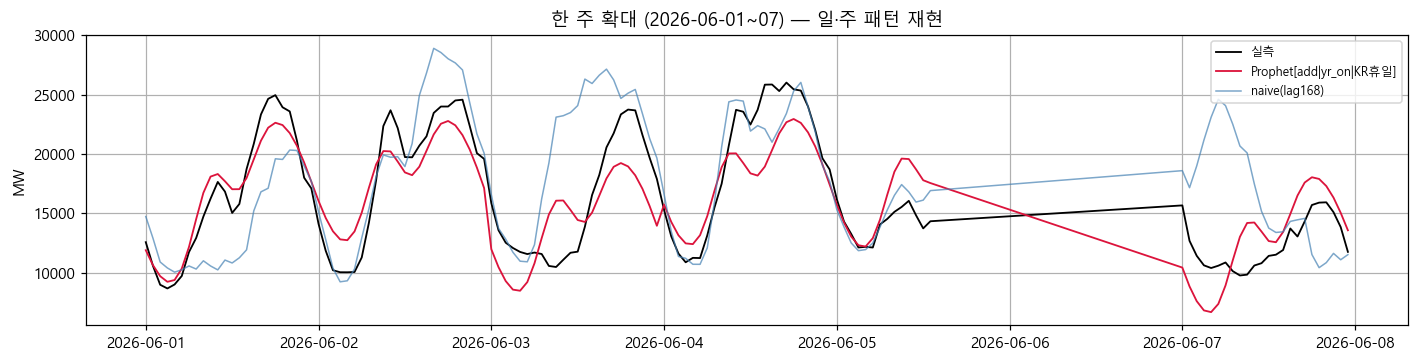

In [ ]:
# 한 주(요일·시각 패턴) 확대 — 6월 첫 주
wk=best_fc[(best_fc.ds>='2026-06-01')&(best_fc.ds<'2026-06-08')]
wn=naive_te[(naive_te.ds>='2026-06-01')&(naive_te.ds<'2026-06-08')]
fig,ax=plt.subplots(figsize=(13,3.4))
ax.plot(wk['ds'], wk['y'], color='black', lw=1.2, label='실측')
ax.plot(wk['ds'], wk['yhat'], color='crimson', lw=1.2, label=best_name)
ax.plot(wn['ds'], wn['yhat'], color='steelblue', lw=1.0, alpha=0.7, label='naive(lag168)')
ax.set_title('한 주 확대 (2026-06-01~07) — 일·주 패턴 재현'); ax.set_ylabel('MW'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'baseline_week_zoom.png'); plt.show()


## 7. 그림 — 모델별 MAPE(val·test) 비교

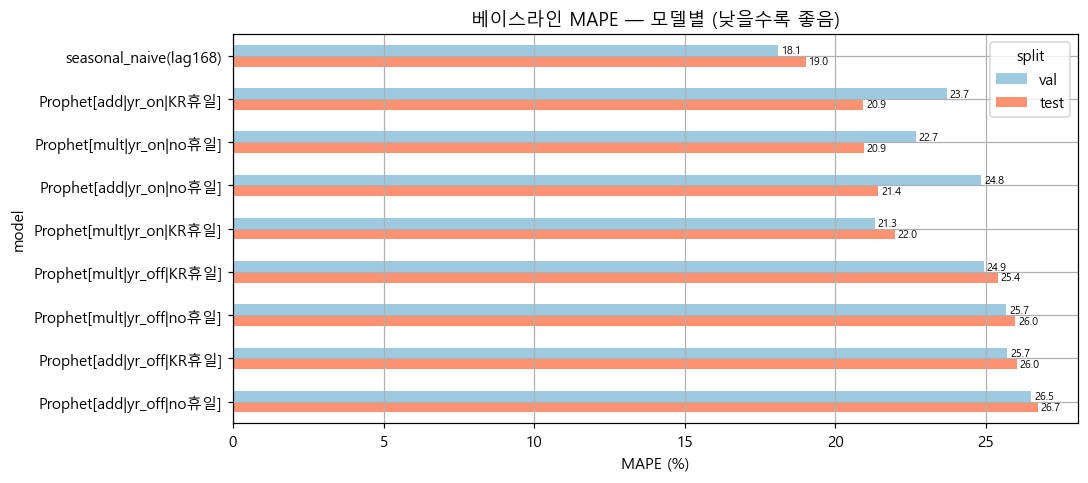

In [ ]:
order=res[res.split=='test'].sort_values('MAPE')['model'].tolist()
piv=res.pivot(index='model', columns='split', values='MAPE').reindex(order)
fig,ax=plt.subplots(figsize=(10,4.5))
piv[['val','test']].plot.barh(ax=ax, color=['#9ecae1','#fc9272'])
ax.invert_yaxis(); ax.set_xlabel('MAPE (%)'); ax.set_title('베이스라인 MAPE — 모델별 (낮을수록 좋음)')
ax.legend(title='split')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)
plt.tight_layout(); plt.savefig(FIG/'baseline_mape_bars.png'); plt.show()


## 8. 요약
- **seasonal naive(lag168)** = 최근 실측(1주 전)을 그대로 쓰는 바닥선. 본 베이스라인 비교의 기준점.
- **Prophet(시간 외삽)** = 외생변수 없이 일·주(·연) 패턴만으로 예측. train 이후를 순수 외삽한 값이라 지평이 길수록 불리.
- 본 모델(7-A LGBM, test MAPE 11.4% / R² 0.78)과의 격차 = **net_load(수요+신재생) 정보가 기여하는 몫**. 베이스라인이 이 격차의 하한을 정량화한다.
- 상세 수치·결론은 `REPORT_baseline.md` 참조.
